<a href="https://colab.research.google.com/github/HurtovaAlina/ITStep-AI/blob/superwised_learning/Home_work_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")
df = df.drop(columns="Posted On")

[Ігформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [3]:
df.head()

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


In [4]:
df.shape

(4746, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4746 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   BHK                4342 non-null   float64
 1   Rent               4369 non-null   float64
 2   Size               4402 non-null   float64
 3   Floor              4380 non-null   object 
 4   Area Type          4390 non-null   object 
 5   Area Locality      4347 non-null   object 
 6   City               4388 non-null   object 
 7   Furnishing Status  4395 non-null   object 
 8   Tenant Preferred   4372 non-null   object 
 9   Bathroom           4387 non-null   float64
 10  Point of Contact   4372 non-null   object 
dtypes: float64(4), object(7)
memory usage: 444.9+ KB


In [7]:
df.isna().sum()

,0
BHK,404
Rent,377
Size,344
Floor,366
Area Type,356
Area Locality,399
City,358
Furnishing Status,351
Tenant Preferred,374
Bathroom,359


In [8]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4342.000000,4.369000e+03,4402.000000,4387.000000
mean,2.082220,3.461306e+04,967.214675,1.970139
std,0.827656,7.740818e+04,636.118893,0.886784
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [9]:
df.dtypes

,0
BHK,float64
Rent,float64
Size,float64
Floor,object
Area Type,object
Area Locality,object
City,object
Furnishing Status,object
Tenant Preferred,object
Bathroom,float64


# Завдання 1
* Очистіть дані від викидів
* Отримайте ознаки та цільову змінну(X, y)
* Розділіть дані на тренувальні та тестові

<Axes: >

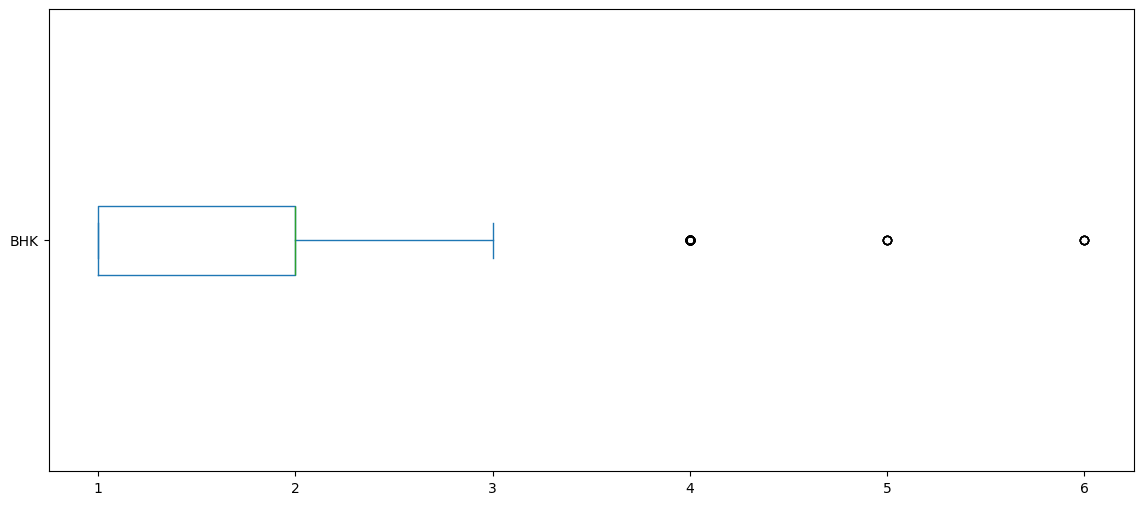

In [37]:
# Очистіть дані від викидів
df['BHK'].plot(kind='box', vert=False, figsize=(14,6))

In [46]:
mask= df['Rent']<100000
mask.sum()

np.int64(3777)

In [47]:
df = df[mask]

<Axes: >

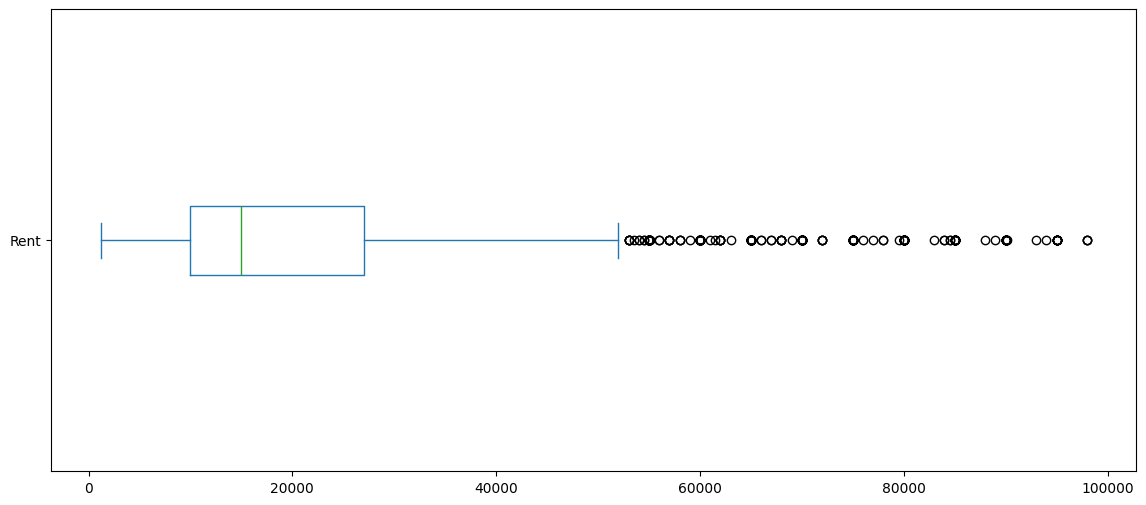

In [48]:
df['Rent'].plot(kind='box', vert=False, figsize=(14,6))

In [52]:
mask= df['Size']<3500
mask.sum()

np.int64(3772)

In [53]:
df = df[mask]

<Axes: >

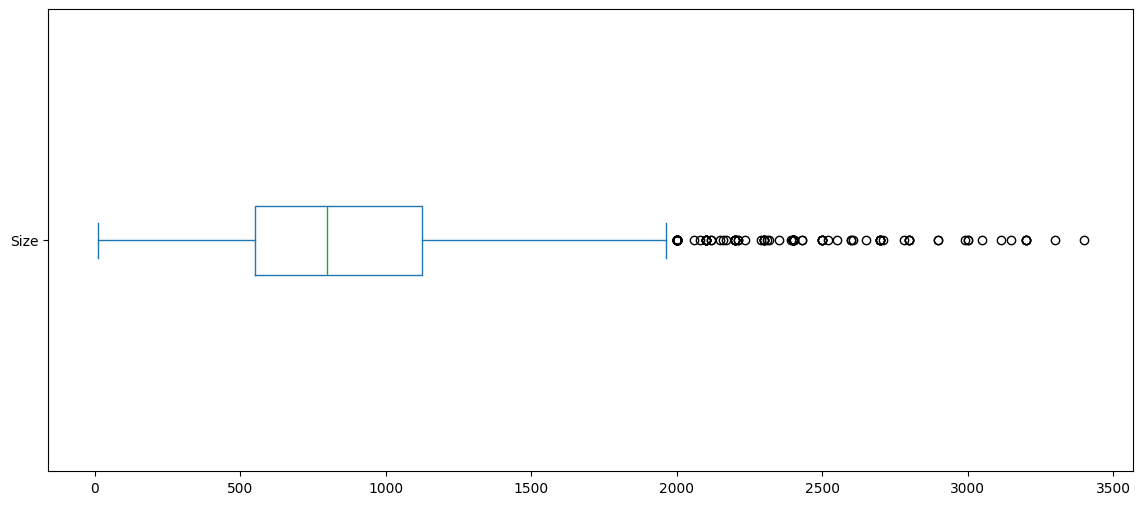

In [54]:
df['Size'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

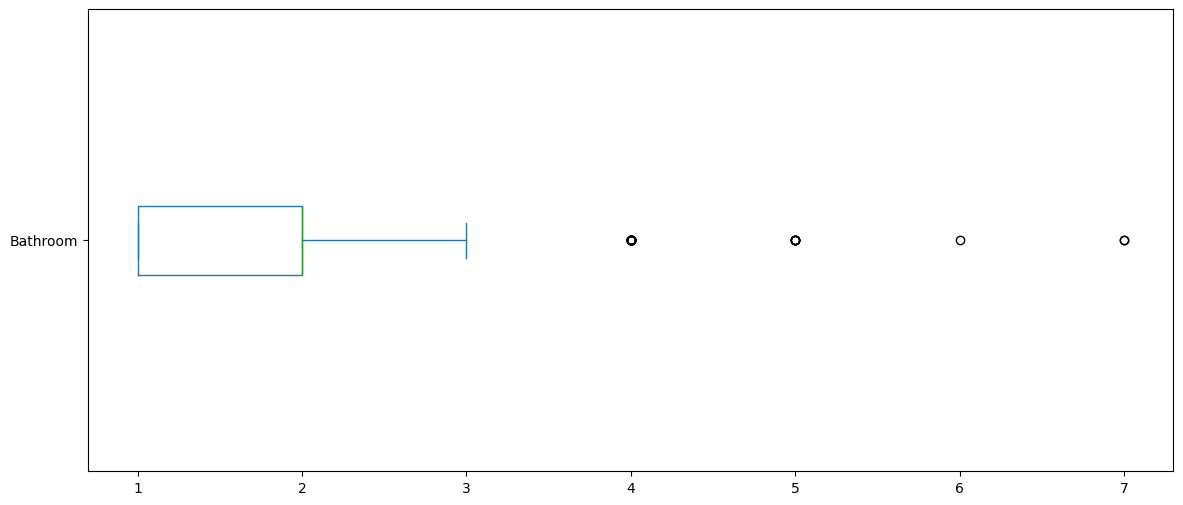

In [55]:
df['Bathroom'].plot(kind='box', vert=False, figsize=(14,6))

In [56]:
df.shape

(3772, 11)

In [58]:
# Отримайте ознаки та цільову змінну(X, y) - прогнозуємо вартість оренди
# y — цільова змінна, X — ознаки

y = df['Rent']
X = df.drop(columns='Rent')

X.head()

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,2.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


In [59]:
X

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,2.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner
...,...,...,...,...,...,...,...,...,...,...
4741,NaN,1000.0,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2.0,Contact Owner
4742,3.0,2000.0,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Owner
4743,3.0,1750.0,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Agent
4744,3.0,1500.0,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2.0,Contact Agent


In [60]:
y

,Rent
0,10000.0
1,20000.0
2,17000.0
3,10000.0
4,7500.0
...,...
4741,15000.0
4742,29000.0
4743,35000.0
4744,45000.0


In [61]:
# Розділіть дані на тренувальні та тестові
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.8,
                                                    random_state=42
                                                    )

X_train.shape, X_test.shape

((3017, 10), (755, 10))

# Завдання 2
Створіть Pipeline для обробки даних числових та категоріальних даних

In [62]:
# побудова пайплайну
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [63]:
# поділ колонок на числові і тестові значення
num_columns = X_train.select_dtypes(include='number').columns
cat_columns = X_train.select_dtypes(include='object').columns

In [64]:
# колонки з числовими значеннями
num_columns

Index(['BHK', 'Size', 'Bathroom'], dtype='object')

In [65]:
# колонки з текстовими значеннями
cat_columns

Index(['Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status',
       'Tenant Preferred', 'Point of Contact'],
      dtype='object')

In [66]:
# пайплайн для числових значень - якщо є пропуски числових значень, заповнює медіанним значенням
num_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

num_transformer

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler())])

In [67]:
# пайплайн для тесктових значень, якщо є пропуски, заповнить значенням Unknown
# handle_unknown='ignore' Якщо не зустрічав таке значення під час навчання, не буде падати з помилкою — просто закодує цю категорію як усі нулі.
cat_transformer = Pipeline(
    [
        ('impute', SimpleImputer(strategy='constant',   # strategy='most_frequent'
                                 fill_value='UNKNOWN')),
         ('onehot', OneHotEncoder(sparse_output=False,
        handle_unknown='ignore'))
    ]
)

cat_transformer

Pipeline(steps=[('impute',
                 SimpleImputer(fill_value='UNKNOWN', strategy='constant')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

# Завдання 3
Об'єднайте препроцесор з деревом рішень в один пайплайн

In [68]:
# препроцессор будує таблицю заповнену числовими значеннями (в т.ч тесктові преобразовані в числові)
preprocessor = ColumnTransformer(
    [
        ('num', num_transformer, num_columns),
        ('cat', cat_transformer, cat_columns)
    ]
)

preprocessor.set_output(transform='pandas')
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 Index(['BHK', 'Size', 'Bathroom'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(fill_value='UNKNOWN',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status',
       'Tenant Preferred', 'Point of Contact'],
      dtype='object'))])

In [69]:
X_train

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
3395,2.0,1120.0,2 out of 4,Super Area,Porur,Chennai,Semi-Furnished,Bachelors/Family,2.0,Contact Owner
2131,NaN,500.0,2 out of 4,Carpet Area,"Aecs Layout-Singasandra, Singasandra, Hosur Road",Bangalore,Unfurnished,Bachelors,1.0,Contact Owner
3045,NaN,1000.0,Ground out of 2,Super Area,Tambaram Sanatorium,Chennai,Semi-Furnished,Bachelors/Family,NaN,Contact Owner
4364,3.0,1150.0,2 out of 4,Carpet Area,"Pragathi Nagar, Moosapet",Hyderabad,Semi-Furnished,Family,3.0,Contact Owner
4500,NaN,1050.0,Ground out of 3,Super Area,Hastinapuram,Hyderabad,Unfurnished,Bachelors/Family,2.0,Contact Owner
...,...,...,...,...,...,...,...,...,...,...
1543,3.0,2000.0,23 out of 40,Carpet Area,Hebbal,Bangalore,Semi-Furnished,Bachelors,3.0,Contact Agent
1737,2.0,500.0,1 out of 2,Carpet Area,"Ombr Layout, Banaswadi",Bangalore,Semi-Furnished,NaN,2.0,Contact Owner
1152,3.0,1000.0,4 out of 11,Carpet Area,"Lodha Eternis, Chakala MIDC",Mumbai,Semi-Furnished,Bachelors/Family,3.0,Contact Agent
4418,3.0,2235.0,Ground out of 10,Carpet Area,Gachibowli,Hyderabad,Unfurnished,Family,5.0,NaN


In [72]:
# трансформація таблиці
X_train_transformed = preprocessor.fit_transform(X_train)

In [73]:
# вивід тренувальної таблиці
X_train_transformed

,num__BHK,num__Size,num__Bathroom,cat__Floor_1,cat__Floor_1 out of 1,cat__Floor_1 out of 10,cat__Floor_1 out of 11,cat__Floor_1 out of 12,cat__Floor_1 out of 13,cat__Floor_1 out of 15,...,cat__Furnishing Status_UNKNOWN,cat__Furnishing Status_Unfurnished,cat__Tenant Preferred_Bachelors,cat__Tenant Preferred_Bachelors/Family,cat__Tenant Preferred_Family,cat__Tenant Preferred_UNKNOWN,cat__Point of Contact_Contact Agent,cat__Point of Contact_Contact Builder,cat__Point of Contact_Contact Owner,cat__Point of Contact_UNKNOWN
3395,0.015407,0.490146,0.205964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2131,0.015407,-0.784032,-1.235785,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3045,0.015407,0.243531,0.205964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4364,1.423964,0.551800,1.647714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4500,0.015407,0.346287,0.205964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,1.423964,2.298657,1.647714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1737,0.015407,-0.784032,0.205964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1152,1.423964,0.243531,1.647714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4418,1.423964,2.781612,4.531213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [78]:
# остаточна модель - побудова дерева рішень

from sklearn.tree import DecisionTreeRegressor


full_model = Pipeline([
    ('prep', preprocessor),
    ('tree', DecisionTreeRegressor(max_depth=4,
                                   min_samples_leaf=5,
                                   random_state=42))
])

In [79]:
full_model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['BHK', 'Size', 'Bathroom'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='UNKNOWN',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status',
       'Tenant Preferred', 'Point of Contact'],
      dtype='object'))])),
                ('tree',
                 DecisionTreeRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=42))])

In [80]:
# натренувати модель
full_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['BHK', 'Size', 'Bathroom'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='UNKNOWN',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status',
       'Tenant Preferred', 'Point of Contact'],
      dtype='object'))])),
                ('tree',
                 DecisionTreeRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=42))])

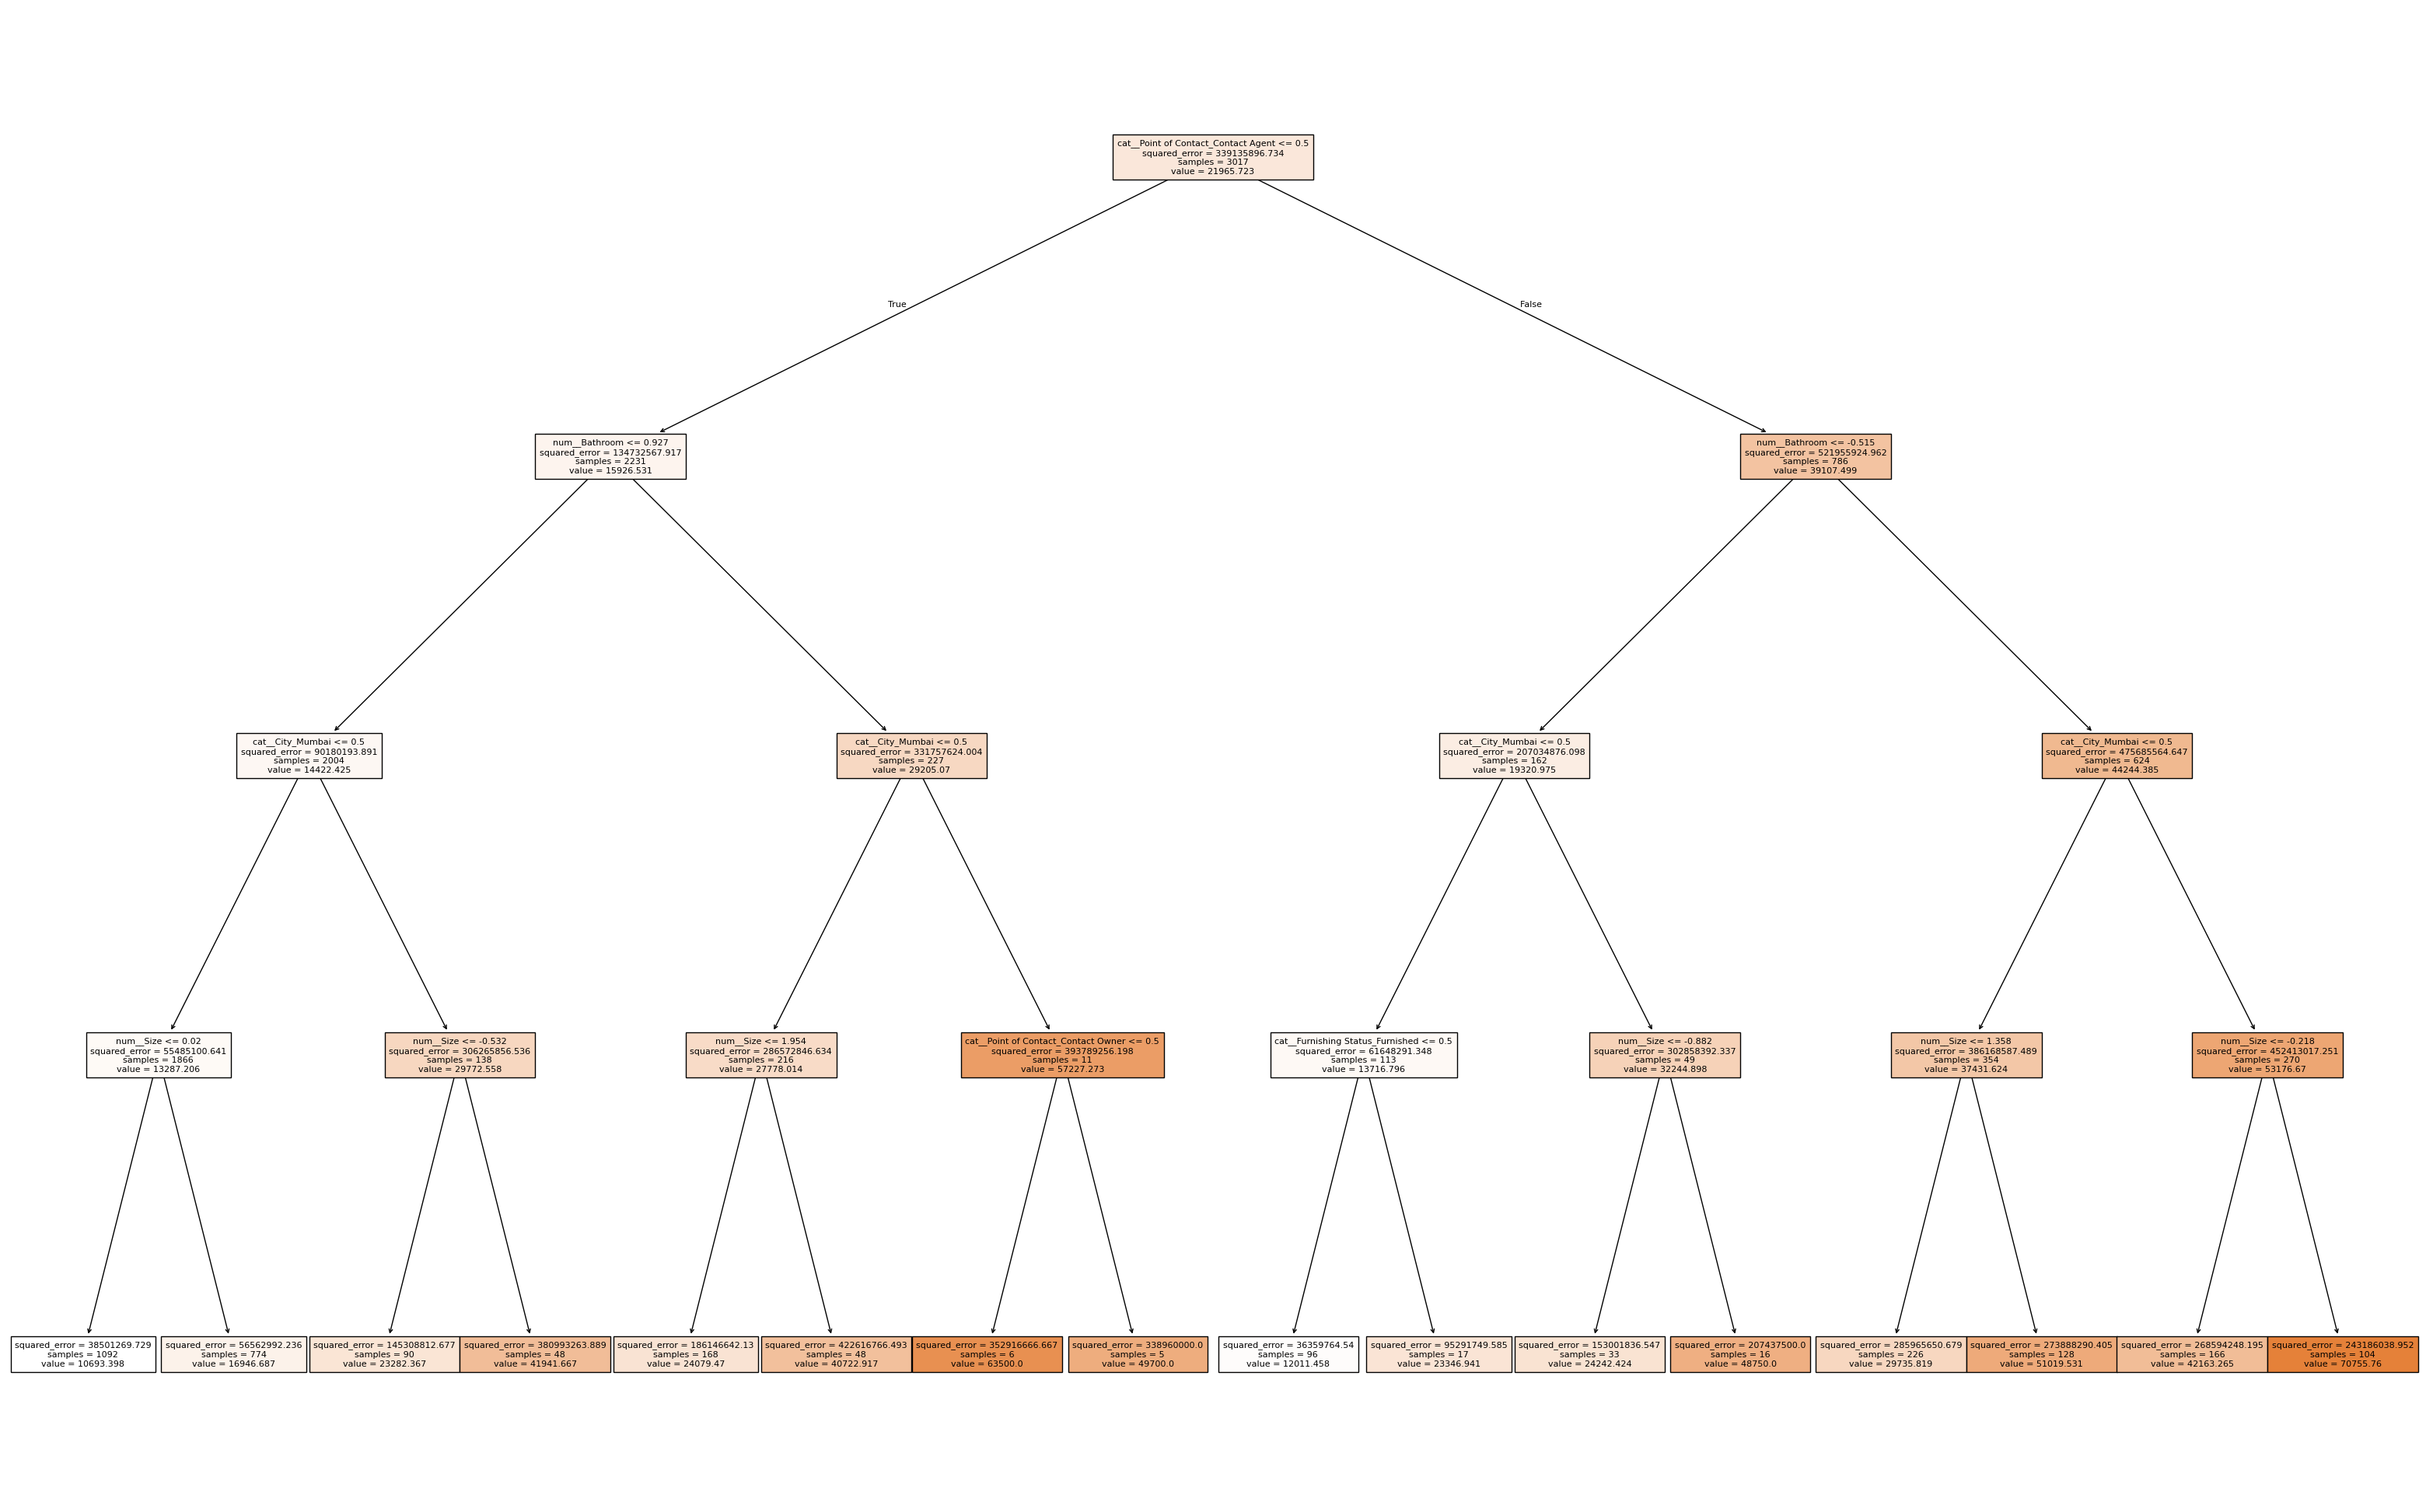

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
# перегляд дерева та збереження його у файл

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from google.colab import files

# дістаємо саме дерево з Pipeline
tree = full_model.named_steps['tree']

# отримуємо назви ознак після preprocessing
feature_names = full_model.named_steps['prep'].get_feature_names_out()

# створюємо малюнок
plt.figure(figsize=(40, 25))

plot_tree(
    tree,
    filled=True,
    feature_names=feature_names,
    fontsize=8
)

# зберігаємо дерево у PDF
plt.savefig(
    'decision_tree.pdf',
    bbox_inches='tight'
)

plt.show()

# завантажуємо PDF на комп'ютер
files.download('decision_tree.pdf')

# Завдання 4
Виведіть основні метрики моделі

In [82]:
from sklearn import metrics

In [83]:
y_pred = full_model.predict(X_test)

In [84]:
y_pred

array([16946.6873385 , 10693.39835165, 16946.6873385 , 40722.91666667,
       24079.4702381 , 29735.81858407, 16946.6873385 , 70755.75961538,
       23282.36666667, 16946.6873385 , 24079.4702381 , 10693.39835165,
       10693.39835165, 16946.6873385 , 24079.4702381 , 42163.26506024,
       10693.39835165, 10693.39835165, 16946.6873385 , 10693.39835165,
       24079.4702381 , 10693.39835165, 16946.6873385 , 16946.6873385 ,
       10693.39835165, 10693.39835165, 16946.6873385 , 12011.45833333,
       70755.75961538, 40722.91666667, 10693.39835165, 24079.4702381 ,
       29735.81858407, 12011.45833333, 10693.39835165, 16946.6873385 ,
       10693.39835165, 42163.26506024, 16946.6873385 , 12011.45833333,
       16946.6873385 , 24079.4702381 , 40722.91666667, 70755.75961538,
       16946.6873385 , 10693.39835165, 10693.39835165, 24079.4702381 ,
       16946.6873385 , 29735.81858407, 49700.        , 16946.6873385 ,
       16946.6873385 , 24079.4702381 , 16946.6873385 , 16946.6873385 ,
      

In [85]:
# копія таблиці
result = X_test.copy()

In [86]:
# додаємо реальну ціну оренди
result['actual__rent'] = y_test.values

# додаємо передбачену ціну оренди
result['predicted_rent'] = y_pred

# показуємо таблицю
result

# X_test → характеристики квартири
# actual_rent → справжня ціна оренди з y_test
# predicted_rent → ціна оренди, яку передбачила модель

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,actual__rent,predicted_rent
302,NaN,1200.0,Ground out of 2,Carpet Area,"Pathak Para, Behala",Kolkata,Unfurnished,Bachelors,2.0,Contact Owner,15000.0,16946.687339
2673,1.0,600.0,1 out of 4,Carpet Area,Chattarpur Extension,Delhi,Semi-Furnished,Bachelors,1.0,Contact Owner,8500.0,10693.398352
4612,2.0,1200.0,5 out of 5,Carpet Area,"Manikonda, Outer Ring Road",NaN,Semi-Furnished,Bachelors,2.0,Contact Owner,17000.0,16946.687339
4057,3.0,2000.0,1 out of 1,Carpet Area,NaN,Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Owner,20000.0,40722.916667
2190,2.0,1600.0,Ground out of 2,Super Area,Kodigehalli,Bangalore,Furnished,Bachelors/Family,3.0,Contact Owner,22000.0,24079.470238
...,...,...,...,...,...,...,...,...,...,...,...,...
1406,1.0,450.0,1 out of 5,Super Area,Andheri West,NaN,Furnished,Bachelors/Family,1.0,Contact Owner,32000.0,10693.398352
4260,2.0,800.0,2 out of 2,Super Area,NaN,Hyderabad,Semi-Furnished,NaN,2.0,Contact Owner,15500.0,10693.398352
3576,NaN,1200.0,9 out of 11,Carpet Area,"Chromepet, GST Road",Chennai,Semi-Furnished,Bachelors/Family,3.0,Contact Agent,25000.0,29735.818584
4462,2.0,1350.0,20 out of 35,Carpet Area,Gachibowli,NaN,Furnished,Bachelors,2.0,Contact Agent,45000.0,29735.818584


In [88]:
# помилка прогнозу
result['difference'] = (
    result['actual__rent'] - result['predicted_rent']
)

result

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,actual__rent,predicted_rent,difference
302,NaN,1200.0,Ground out of 2,Carpet Area,"Pathak Para, Behala",Kolkata,Unfurnished,Bachelors,2.0,Contact Owner,15000.0,16946.687339,-1946.687339
2673,1.0,600.0,1 out of 4,Carpet Area,Chattarpur Extension,Delhi,Semi-Furnished,Bachelors,1.0,Contact Owner,8500.0,10693.398352,-2193.398352
4612,2.0,1200.0,5 out of 5,Carpet Area,"Manikonda, Outer Ring Road",NaN,Semi-Furnished,Bachelors,2.0,Contact Owner,17000.0,16946.687339,53.312661
4057,3.0,2000.0,1 out of 1,Carpet Area,NaN,Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Owner,20000.0,40722.916667,-20722.916667
2190,2.0,1600.0,Ground out of 2,Super Area,Kodigehalli,Bangalore,Furnished,Bachelors/Family,3.0,Contact Owner,22000.0,24079.470238,-2079.470238
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1406,1.0,450.0,1 out of 5,Super Area,Andheri West,NaN,Furnished,Bachelors/Family,1.0,Contact Owner,32000.0,10693.398352,21306.601648
4260,2.0,800.0,2 out of 2,Super Area,NaN,Hyderabad,Semi-Furnished,NaN,2.0,Contact Owner,15500.0,10693.398352,4806.601648
3576,NaN,1200.0,9 out of 11,Carpet Area,"Chromepet, GST Road",Chennai,Semi-Furnished,Bachelors/Family,3.0,Contact Agent,25000.0,29735.818584,-4735.818584
4462,2.0,1350.0,20 out of 35,Carpet Area,Gachibowli,NaN,Furnished,Bachelors,2.0,Contact Agent,45000.0,29735.818584,15264.181416


In [89]:
# знайти всі великі відхилення
result['abs_difference'] = result['difference'].abs()

result.sort_values(
    'abs_difference',
    ascending=False
).head(10)

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,actual__rent,predicted_rent,difference,abs_difference
2187,2.0,950.0,4 out of 5,Carpet Area,Aarna Enclave,Bangalore,Unfurnished,Bachelors/Family,2.0,Contact Owner,90000.0,16946.687339,73053.312661,73053.312661
1470,2.0,800.0,5 out of 6,Carpet Area,Vile Parle West,NaN,Furnished,Family,2.0,Contact Agent,90000.0,29735.818584,60264.181416,60264.181416
1054,2.0,750.0,7 out of 10,Carpet Area,Opera House,Mumbai,Furnished,Bachelors,2.0,NaN,95000.0,41941.666667,53058.333333,53058.333333
3799,3.0,1450.0,NaN,Super Area,Madipakkam,Chennai,NaN,Bachelors/Family,2.0,Contact Owner,70000.0,16946.687339,53053.312661,53053.312661
655,2.0,780.0,17 out of 22,NaN,"Man Opus, Mira Road",Mumbai,Unfurnished,Family,2.0,Contact Agent,18000.0,70755.759615,-52755.759615,52755.759615
1908,3.0,1480.0,7 out of 14,Carpet Area,NaN,Bangalore,Furnished,Family,2.0,NaN,65000.0,16946.687339,48053.312661,48053.312661
1556,4.0,3150.0,8 out of 19,Carpet Area,Banashankari,Bangalore,Unfurnished,Bachelors,4.0,Contact Owner,84000.0,40722.916667,43277.083333,43277.083333
3584,6.0,1800.0,1 out of 3,Super Area,Besant Nagar,Chennai,Furnished,Bachelors/Family,NaN,Contact Owner,60000.0,16946.687339,43053.312661,43053.312661
578,2.0,700.0,NaN,Carpet Area,"Lodha New Cuffe Parade, Wadala",Mumbai,Semi-Furnished,Bachelors/Family,2.0,Contact Agent,85000.0,42163.265060,42836.734940,42836.734940
1272,2.0,550.0,1 out of 7,Super Area,"Dr Babasaheb Ambedkar Road, Mumbai",Mumbai,Semi-Furnished,Bachelors/Family,2.0,Contact Owner,65000.0,23282.366667,41717.633333,41717.633333


In [90]:
result['error_percent'] = (
    result['difference'].abs()
    / result['actual__rent']
    * 100
)

In [91]:
result.sort_values(
    'error_percent',
    ascending=False
).head(10)

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,actual__rent,predicted_rent,difference,abs_difference,error_percent
404,1.0,300.0,NaN,NaN,Barrackpore,Kolkata,Unfurnished,NaN,NaN,Contact Agent,5000.0,29735.818584,-24735.818584,24735.818584,494.716372
2475,2.0,60.0,1 out of 1,Super Area,Ram Nagar,Delhi,Unfurnished,Bachelors/Family,NaN,Contact Owner,2000.0,10693.398352,-8693.398352,8693.398352,434.669918
1583,1.0,800.0,1 out of 1,Carpet Area,Babusapalya,Bangalore,Unfurnished,Bachelors/Family,NaN,Contact Agent,7000.0,29735.818584,-22735.818584,22735.818584,324.797408
437,1.0,500.0,Ground out of 2,Super Area,NaN,Kolkata,Semi-Furnished,Bachelors/Family,2.0,Contact Agent,7000.0,29735.818584,-22735.818584,22735.818584,324.797408
86,2.0,700.0,Ground out of 2,Carpet Area,Dum Dum Metro,Kolkata,Semi-Furnished,Bachelors/Family,2.0,Contact Agent,7000.0,29735.818584,-22735.818584,22735.818584,324.797408
655,2.0,780.0,17 out of 22,NaN,"Man Opus, Mira Road",Mumbai,Unfurnished,Family,2.0,Contact Agent,18000.0,70755.759615,-52755.759615,52755.759615,293.087553
306,1.0,500.0,Ground out of 1,Super Area,Hatiara,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner,3000.0,10693.398352,-7693.398352,7693.398352,256.446612
511,3.0,900.0,1 out of 2,Super Area,"Michael Nagar, New Barrakpur",Kolkata,Semi-Furnished,Bachelors/Family,3.0,Contact Owner,7000.0,24079.470238,-17079.470238,17079.470238,243.992432
249,3.0,800.0,1 out of 3,Carpet Area,Bhawanipur,Kolkata,Furnished,Bachelors/Family,2.0,Contact Owner,3200.0,10693.398352,-7493.398352,7493.398352,234.168698
1456,1.0,480.0,4 out of 4,Carpet Area,Taloja Phase 2,Mumbai,Unfurnished,Bachelors/Family,1.0,Contact Owner,7000.0,23282.366667,-16282.366667,16282.366667,232.605238


In [92]:
df['Rent'].describe()

,Rent
count,3772.000000
mean,21958.894486
std,18550.874856
min,1200.000000
25%,10000.000000
50%,15000.000000
75%,27000.000000
max,98000.000000


In [93]:
df['Rent'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,Rent
0.01,4000.0
0.05,6000.0
0.25,10000.0
0.50,15000.0
0.75,27000.0
0.95,65000.0
0.99,89290.0


In [110]:
from sklearn import metrics

In [111]:
y_pred = full_model.predict(X_test)

metrics.r2_score(y_pred, y_test)

0.441998999565959

# Завдання 5
Змініть параметри моделі та попробуйте покращити результат та натренуйте його

In [95]:
# скільки квапртир дешевше 10000
df[df['Rent'] <= 10000]['Rent'].describe()

,Rent
count,1140.000000
mean,7653.782456
std,1821.494182
min,1200.000000
25%,6500.000000
50%,8000.000000
75%,9000.000000
max,10000.000000


In [96]:
# вартість в залежності від міста
df.groupby('City')['Rent'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('median')

,count,mean,median,min,max
City,,,,,
Kolkata,430,11280.862791,8500.0,1500.0,60000.0
Bangalore,676,17857.072485,14000.0,3500.0,90000.0
Hyderabad,659,17723.520486,14000.0,1200.0,95000.0
Chennai,685,17542.725547,14000.0,3000.0,90000.0
Delhi,463,22377.323974,16500.0,2000.0,95000.0
Mumbai,582,44731.465636,42000.0,5500.0,98000.0


In [97]:
df.groupby('City')['Rent'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('median')

,count,mean,median,min,max
City,,,,,
Kolkata,430,11280.862791,8500.0,1500.0,60000.0
Bangalore,676,17857.072485,14000.0,3500.0,90000.0
Hyderabad,659,17723.520486,14000.0,1200.0,95000.0
Chennai,685,17542.725547,14000.0,3000.0,90000.0
Delhi,463,22377.323974,16500.0,2000.0,95000.0
Mumbai,582,44731.465636,42000.0,5500.0,98000.0


In [98]:
new_full_model = Pipeline([
    ('prep', preprocessor),

    ('tree', DecisionTreeRegressor(
        max_depth=15,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=42
    ))
])

In [99]:
new_full_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['BHK', 'Size', 'Bathroom'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='UNKNOWN',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status',
       'Tenant Preferred', 'Point of Contact'],
      dtype='object'))])),
                ('tree',
                 DecisionTreeRegressor(max_depth=15, min_samples_leaf=5,
                                       min_samples_split=10,
                                       random_state=42))])

In [100]:
new_y_pred = new_full_model.predict(X_test)

In [101]:
new_y_pred

array([14833.33333333,  8427.77777778, 17124.56140351, 23333.33333333,
       25875.        , 23625.        , 13168.91891892, 86012.5       ,
       18000.        , 13545.45454545, 17636.36363636,  8000.        ,
       12023.42727273, 12600.        , 22571.42857143, 36214.28571429,
        8001.11111111, 13200.        , 13055.55555556,  8001.11111111,
       21166.66666667, 11885.71428571, 15700.        , 15107.14285714,
        8875.        ,  8740.        , 12666.66666667,  9071.42857143,
       67000.        , 38444.44444444, 11110.34482759, 27142.85714286,
       33166.66666667, 19944.44444444, 12023.42727273, 17200.        ,
       19250.        , 32055.55555556, 19000.        , 14000.        ,
       24333.33333333, 14800.        , 38444.44444444, 69714.28571429,
       12500.        ,  5500.        , 12023.42727273, 17200.        ,
       11800.        , 58042.85714286, 49700.        , 10750.        ,
       15571.42857143, 10500.        , 10750.        , 17124.56140351,
      

In [102]:
new_result = X_test.copy()
# додаємо реальну ціну оренди
new_result['new_actual__rent'] = y_test.values

# додаємо передбачену ціну оренди
new_result['new_predicted_rent'] = new_y_pred

# показуємо таблицю
new_result

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,new_actual__rent,new_predicted_rent
302,NaN,1200.0,Ground out of 2,Carpet Area,"Pathak Para, Behala",Kolkata,Unfurnished,Bachelors,2.0,Contact Owner,15000.0,14833.333333
2673,1.0,600.0,1 out of 4,Carpet Area,Chattarpur Extension,Delhi,Semi-Furnished,Bachelors,1.0,Contact Owner,8500.0,8427.777778
4612,2.0,1200.0,5 out of 5,Carpet Area,"Manikonda, Outer Ring Road",NaN,Semi-Furnished,Bachelors,2.0,Contact Owner,17000.0,17124.561404
4057,3.0,2000.0,1 out of 1,Carpet Area,NaN,Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Owner,20000.0,23333.333333
2190,2.0,1600.0,Ground out of 2,Super Area,Kodigehalli,Bangalore,Furnished,Bachelors/Family,3.0,Contact Owner,22000.0,25875.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
1406,1.0,450.0,1 out of 5,Super Area,Andheri West,NaN,Furnished,Bachelors/Family,1.0,Contact Owner,32000.0,8001.111111
4260,2.0,800.0,2 out of 2,Super Area,NaN,Hyderabad,Semi-Furnished,NaN,2.0,Contact Owner,15500.0,9530.000000
3576,NaN,1200.0,9 out of 11,Carpet Area,"Chromepet, GST Road",Chennai,Semi-Furnished,Bachelors/Family,3.0,Contact Agent,25000.0,21799.800000
4462,2.0,1350.0,20 out of 35,Carpet Area,Gachibowli,NaN,Furnished,Bachelors,2.0,Contact Agent,45000.0,55277.777778


In [105]:
# помилка прогнозу
new_result['difference'] = (
    new_result['new_actual__rent'] - new_result['new_predicted_rent']
)

new_result

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,new_actual__rent,new_predicted_rent,difference
302,NaN,1200.0,Ground out of 2,Carpet Area,"Pathak Para, Behala",Kolkata,Unfurnished,Bachelors,2.0,Contact Owner,15000.0,14833.333333,166.666667
2673,1.0,600.0,1 out of 4,Carpet Area,Chattarpur Extension,Delhi,Semi-Furnished,Bachelors,1.0,Contact Owner,8500.0,8427.777778,72.222222
4612,2.0,1200.0,5 out of 5,Carpet Area,"Manikonda, Outer Ring Road",NaN,Semi-Furnished,Bachelors,2.0,Contact Owner,17000.0,17124.561404,-124.561404
4057,3.0,2000.0,1 out of 1,Carpet Area,NaN,Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Owner,20000.0,23333.333333,-3333.333333
2190,2.0,1600.0,Ground out of 2,Super Area,Kodigehalli,Bangalore,Furnished,Bachelors/Family,3.0,Contact Owner,22000.0,25875.000000,-3875.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1406,1.0,450.0,1 out of 5,Super Area,Andheri West,NaN,Furnished,Bachelors/Family,1.0,Contact Owner,32000.0,8001.111111,23998.888889
4260,2.0,800.0,2 out of 2,Super Area,NaN,Hyderabad,Semi-Furnished,NaN,2.0,Contact Owner,15500.0,9530.000000,5970.000000
3576,NaN,1200.0,9 out of 11,Carpet Area,"Chromepet, GST Road",Chennai,Semi-Furnished,Bachelors/Family,3.0,Contact Agent,25000.0,21799.800000,3200.200000
4462,2.0,1350.0,20 out of 35,Carpet Area,Gachibowli,NaN,Furnished,Bachelors,2.0,Contact Agent,45000.0,55277.777778,-10277.777778


In [106]:
# знайти всі великі відхилення
new_result['abs_difference'] = new_result['difference'].abs()

new_result.sort_values(
    'abs_difference',
    ascending=False
).head(10)

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,new_actual__rent,new_predicted_rent,difference,abs_difference
2187,2.0,950.0,4 out of 5,Carpet Area,Aarna Enclave,Bangalore,Unfurnished,Bachelors/Family,2.0,Contact Owner,90000.0,13168.918919,76831.081081,76831.081081
655,2.0,780.0,17 out of 22,NaN,"Man Opus, Mira Road",Mumbai,Unfurnished,Family,2.0,Contact Agent,18000.0,65799.800000,-47799.800000,47799.800000
2630,3.0,1500.0,1 out of 1,Carpet Area,NaN,Delhi,Unfurnished,Bachelors/Family,3.0,Contact Owner,8000.0,54285.714286,-46285.714286,46285.714286
3799,3.0,1450.0,NaN,Super Area,Madipakkam,Chennai,NaN,Bachelors/Family,2.0,Contact Owner,70000.0,25666.666667,44333.333333,44333.333333
2541,3.0,1700.0,1 out of 4,Carpet Area,"Shivalik, Malviya Nagar",Delhi,Furnished,Bachelors,3.0,Contact Agent,80000.0,36571.428571,43428.571429,43428.571429
578,2.0,700.0,NaN,Carpet Area,"Lodha New Cuffe Parade, Wadala",Mumbai,Semi-Furnished,Bachelors/Family,2.0,Contact Agent,85000.0,45700.000000,39300.000000,39300.000000
3584,6.0,1800.0,1 out of 3,Super Area,Besant Nagar,Chennai,Furnished,Bachelors/Family,NaN,Contact Owner,60000.0,23333.333333,36666.666667,36666.666667
2843,3.0,1450.0,2 out of 4,Carpet Area,Lajpat Nagar 3,Delhi,Semi-Furnished,NaN,3.0,Contact Agent,68000.0,31499.857143,36500.142857,36500.142857
1802,3.0,1893.0,Ground out of 18,Super Area,Begur Road,Bangalore,Semi-Furnished,Bachelors,4.0,Contact Agent,30000.0,65500.000000,-35500.000000,35500.000000
2897,1.0,400.0,3 out of 4,Carpet Area,Lajpat Nagar,NaN,Furnished,Bachelors/Family,NaN,Contact Agent,20000.0,55277.777778,-35277.777778,35277.777778


In [109]:
from sklearn import metrics

In [108]:
new_y_pred = new_full_model.predict(X_test)

metrics.r2_score(new_y_pred, y_test)

0.6048678217860892

# Завдання 6
Спрогнозуйте ціну оренди на тестових даних та порівняйте зі справжніми